In [1]:
%matplotlib widget
import ipywidgets as widgets
# from IPython.display import clear_output
import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd
# import numpy as np
from tqdm.autonotebook import tqdm
from scipy.ndimage import gaussian_filter1d
# import h5py
# import copy
import os
import torch
os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

# import shlex

from diffSPH.simple import *
from util import *

# from waveEqn import WaveEquationState, waveEquation2
# from waveEqn import WaveSystem, waveSystemFunction

In [2]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
device = torch.device('cpu')
dtype = torch.float32
L = 1
dim = 2
nx = 32
dx = L/nx

kernel = KernelType.Wendland4
targetNeighbors = n_h_to_nH(4, dim)

domain = buildDomainDescription(L, dim, True, device, dtype)
domain.min = torch.zeros_like(domain.min)
domain.max = torch.ones_like(domain.max) * L

# particles = sampleOptimal(nx, domain, targetNeighbors, kernel, 0.2, 128, shiftScheme = 'delta')
# particles = sampleOptimal(nx, domain, targetNeighbors, kernel, 0.1, 128, shiftScheme = 'delta') 
particles = sampleOptimal(nx, domain, targetNeighbors, kernel, 0., 0, shiftScheme = 'delta') 
particlesLR = sampleOptimal(nx//2, domain, targetNeighbors, kernel, 0., 0, shiftScheme = 'delta')

particles = particles._replace(positions = particles.positions - dx/2)
particlesLR = particlesLR._replace(positions = particlesLR.positions - dx/4)    

config = {
    'domain': domain,
    'kernel': kernel,
    'targetNeighbors': targetNeighbors,
    'neighborhood':{
        'verletScale': 1.0,
        'computeHessian': True,
    }
}

config['gradientMode'] = GradientMode.Difference
config['laplacianMode'] = LaplacianMode.Brookshaw
config['supportScheme'] = SupportScheme.Gather
config['integrationScheme'] = IntegrationSchemeType.rungeKutta4

particleState = wcstateToState(particles)


0it [00:00, ?it/s]

0it [00:00, ?it/s]

In [3]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
import numpy as np
import jax
import exponax as ex
import matplotlib.pyplot as plt
import h5py

NUM_POINTS = nx

datafile = h5py.File(f"data_diffusedNoise_nx_{nx}.h5", "r")

u0 = np.array(datafile['u_0'])
jacobian = np.array(datafile['d'])
hessian = np.array(datafile['d2'])
patrician = np.array(datafile['d3'])

selected_seed = 0

values = [u0[selected_seed], jacobian[selected_seed], hessian[selected_seed], patrician[selected_seed]]
values = [torch.tensor(v, device=device, dtype=dtype).flatten(-2).T for v in values]

for v in values:
    print(v.shape)

torch.Size([1024, 1])
torch.Size([1024, 2])
torch.Size([1024, 2, 2])
torch.Size([1024, 2, 2, 2])


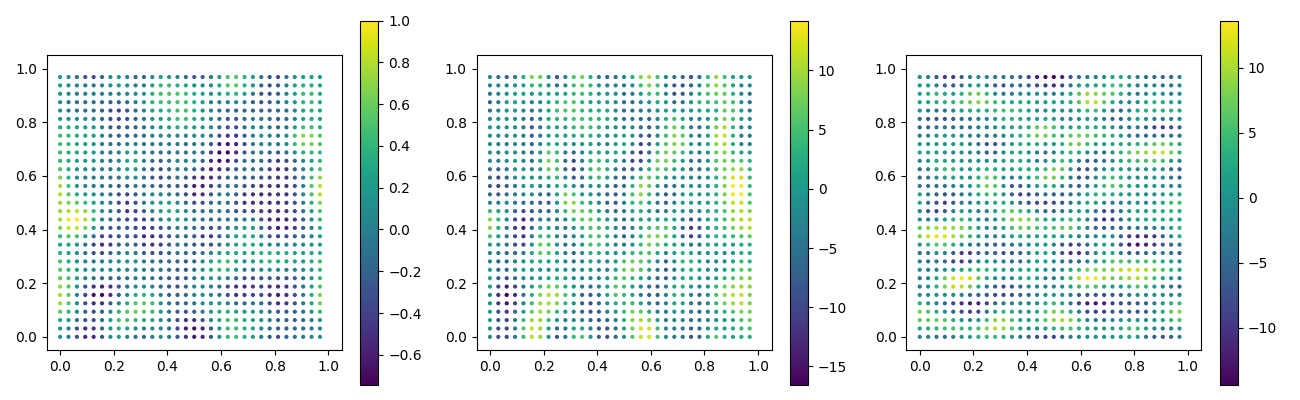

In [4]:
fig, axis = plt.subplots(1, 3, figsize=(13, 4), squeeze = False)

plot = visualizeParticles(fig, axis[0, 0],
  particles = particleState,
  domain = domain,
  quantity = values[0],
  which = 'fluid',
  mapping = '.x',
  cmap = 'viridis',
  visualizeBoth=False,
  kernel = kernel,
  plotDomain = False,
  gridVisualization=False, markerSize=4,
  streamLines = False)

plot = visualizeParticles(fig, axis[0, 1],
  particles = particleState,
  domain = domain,
  quantity = values[1],
  which = 'fluid',
  mapping = '.x',
  cmap = 'viridis',
  visualizeBoth=False,
  kernel = kernel,  
  plotDomain = False,
  gridVisualization=False, markerSize=4,
  streamLines = False)


plot = visualizeParticles(fig, axis[0, 2],
  particles = particleState,
  domain = domain,
  quantity = values[1],
  which = 'fluid',
  mapping = '.y',
  cmap = 'viridis',
  visualizeBoth=False,
  kernel = kernel,
  plotDomain = False,
  gridVisualization=False, markerSize=4,
  streamLines = False)


fig.tight_layout()


In [5]:
from diffSPH.neighborhood import computeSparseDistanceTensor, filterNeighborhood, SparseNeighborhood, NeighborhoodInformation

# @torch.jit.script
def filterNeighborhood(neighborhood: SparseNeighborhood, mode: str = 'superSymmetric'):
    if isinstance(neighborhood, NeighborhoodInformation):
        raise ValueError('Cannot filter neighborhood with NeighborhoodInformation')

    # adjacency = neighborhood.fullAdjacency
    row, col = neighborhood.row, neighborhood.col
    rij, xij = computeSparseDistanceTensor(neighborhood, normalize = True, mode = mode)
    mask = rij <= 1
    # print(mask)
    # print(rij, 'max: ', rij.max().item())
    # print(torch.sum(mask).item(), 'out of', rij.shape[0], 'edges kept')
    return SparseNeighborhood(row[mask], col[mask], numRows = neighborhood.numRows, numCols = neighborhood.numCols,
                                points_a = neighborhood.points_a, points_b = neighborhood.points_b,
                                domain = neighborhood.domain)



def prepNeighborhood(stateA, stateB, mode = SupportScheme.SuperSymmetric, verletScale = 1.0, priorNeighborhood = None):    
    mode_str = mode.name
    mode_str = mode_str[0].lower() + mode_str[1:]

    neighborhood, sparseNeighborhood_ = buildNeighborhood(particleState, particleState, domain, verletScale = verletScale, mode = mode_str, priorNeighborhood=priorNeighborhood)
    neighbors = computeNeighborhoodStates(particleState, sparseNeighborhood_, mode_str, kernel, kernel, True, False, False)


    numNeighbors = coo_to_csr(neighbors.neighbors).rowEntries
    filteredNeighborhood = filterNeighborhood(neighbors.neighbors, mode = 'gather')
    h_i = particleState.supports[filteredNeighborhood.row].to(device)
    rij, xij_ = computeSparseDistanceTensor(filteredNeighborhood, normalize = False)
    sparse_edge_attr = xij_ / h_i[:,None]

    # print('Maximum distance: ', (rij / h_i).max().item())

    return neighbors, filteredNeighborhood, sparse_edge_attr, numNeighbors, neighborhood

    

In [6]:
neighbors, filteredNeighborhood, sparse_edge_attr, numNeighbors, neighborhood = prepNeighborhood(particleState, particleState, mode = config['supportScheme'], verletScale = config['neighborhood']['verletScale'], priorNeighborhood = None)

Number of neighbors: torch.Size([1024]) tensor([45, 45, 45,  ..., 45, 45, 45])
torch.Size([46080])


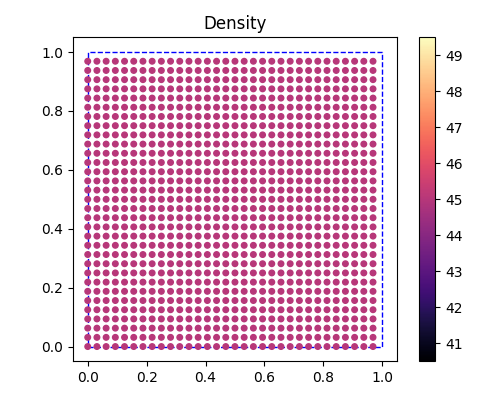

In [7]:
print('Number of neighbors:', numNeighbors.shape, numNeighbors)

fig, axis = plt.subplots(1,1 , figsize=(5,4), squeeze=False)
markerSize = 16
visualizeParticles(fig, axis[0,0], particleState, config['domain'], numNeighbors,
    kernel, which = 'both', visualizeBoth = True, cbar = True, cmap = 'magma', markerSize = markerSize, gridVisualization = False, title = 'Density')

# plotDistribution(fig, axis[0,1], particleState, neighbors.get('noghost'), 63)
fig.tight_layout()


print(neighbors.neighbors.row.shape)

In [8]:
from layers.mlp import MLP, MLPConfig
from blocks.feedForwardNetwork import FeedForwardNetwork
from layers.tokenEncoder import TokenEncoderConfig, TokenEncoder
from layers.tokenMixer import printTensor
import copy

inputFeatures = values[0]

inputFeatures = torch.sin(particleState.positions[:,0].view(-1,1)*2*np.pi)
# 
gt = values[0]**2
gt = inputFeatures**2

node_attr = (inputFeatures.unsqueeze(0), inputFeatures.unsqueeze(0))


In [9]:
from layers.positionEncoder import BasisEncoder
from layers.mlp import MLPConfig

mlpConfig = MLPConfig(
    post_norm = True,
    norm_type = 'layer',
    hidden_dim = 32,
    hidden_layers = 2,
)

bEnc = BasisEncoder(
    verbose = True,

    spatial_dim = 2,
    base_encoding = True,
    base_function = 'pfourier',
    base_terms = 11,
    base_mode = 'cat',

    projection = True,
    projection_linear = True,
    projection_dim = 7,
    projection_bias = False,

    mlpConfig = mlpConfig,
).to(device)


encodedEdges = bEnc(sparse_edge_attr).detach()

#                       Initializing BasisEncoder Layer                        #
BasisEncoder: basis_terms=[11, 11], basis_function=['pfourier', 'pfourier'], mode=cat, spatial_dim=2
	BasisEncoder: basisShape=[22], total basis terms=22
	BasisEncoder: project_out=7, outputShape=7
BasisEncoder: basisShape=[22], total basis terms=22, outputShape=7
BasisEncoder: project_out=True, outputShape=7
BasisEncoder: projector=Linear(in_features=22, out_features=7, bias=False)
BasisEncoder Layer Initialized
#                          BasisEncoder Forward Pass                           #
	Input Positions shape: torch.Size([46080, 2]), min: -0.75, max: 0.75, mean: 0.0, std: 0.47140708565711975
	Input Positions dim 0: min: -0.75, max: 0.75, mean: 0.0, std: 0.4714096486568451
	Input Positions dim 1: min: -0.75, max: 0.75, mean: 0.0, std: 0.4714096486568451
	Input Positions lengths: min: 0.0, max: 0.9013878107070923, mean: 0.6277874708175659, std: 0.22434008121490479
Input positions shape before shapeMatc